### Binomial Tree Monte Carlo
Implement a Binomial tree Monte Carlo simulation to price an option, including defining model parameters, implementing Binomial tree mechanics, performing Monte Carlo simulation, calculating option payoffs, calculating the option price, and visualizing the simulation results.

**Model Parameters**

Initialize all necessary parameters for the Binomial tree (e.g., initial stock price, strike price, time to maturity, volatility, risk-free rate, number of steps) and for the Monte Carlo simulation (e.g., number of simulations).


In [ ]:
S0 = 100          # Initial stock price
K = 100           # Strike price
T = 1             # Time to maturity in years
sigma = 0.20      # Volatility (20%)
r = 0.05          # Risk-free rate (5%)
N = 100           # Number of steps in the Binomial tree

num_simulations = 100000 # Number of simulation paths for Monte Carlo

print(f"Binomial Tree Parameters:\n  Initial Stock Price (S0): {S0}\n  Strike Price (K): {K}\n  Time to Maturity (T): {T} years\n  Volatility (sigma): {sigma}\n  Risk-Free Rate (r): {r}\n  Number of Steps (N): {N}")
print(f"\nMonte Carlo Simulation Parameters:\n  Number of Simulations (num_simulations): {num_simulations}")

Binomial Tree Parameters:
  Initial Stock Price (S0): 100
  Strike Price (K): 100
  Time to Maturity (T): 1 years
  Volatility (sigma): 0.2
  Risk-Free Rate (r): 0.05
  Number of Steps (N): 100

Monte Carlo Simulation Parameters:
  Number of Simulations (num_simulations): 100000


**Implement Binomial Tree Mechanics**

Functions to calculate the 'up' and 'down' factors (u, d) and the risk-neutral probability (p) for the Binomial tree model based on the defined parameters.


In [ ]:
import math

dt = T / N
u = math.exp(sigma * math.sqrt(dt))
d = 1 / u
p = (math.exp(r * dt) - d) / (u - d)

print(f"Binomial Tree Mechanics Parameters:\n  Time Step (dt): {dt:.4f}\n  Up Factor (u): {u:.4f}\n  Down Factor (d): {d:.4f}\n  Risk-Neutral Probability (p): {p:.4f}")

Binomial Tree Mechanics Parameters:
  Time Step (dt): 0.0100
  Up Factor (u): 1.0202
  Down Factor (d): 0.9802
  Risk-Neutral Probability (p): 0.5075


In [ ]:
import math

''' Refactor code: Calculates the time step dt, the up factor (u), the down factor (d), the risk-neutral probability (p)'''
def calculate_dt(T, N):
    return T / N
def calculate_up_factor(sigma, dt):
    return math.exp(sigma * math.sqrt(dt))
def calculate_down_factor(u):
    return 1 / u
def calculate_risk_neutral_probability(r, dt, u, d):
    return (math.exp(r * dt) - d) / (u - d)

# Calculate dt first
dt = calculate_dt(T, N)

# Now calculate u, d, and p using the functions
u = calculate_up_factor(sigma, dt)
d = calculate_down_factor(u)
p = calculate_risk_neutral_probability(r, dt, u, d)

print(f"Binomial Tree Mechanics Parameters (from functions):\n  Time Step (dt): {dt:.4f}\n  Up Factor (u): {u:.4f}\n  Down Factor (d): {d:.4f}\n  Risk-Neutral Probability (p): {p:.4f}")

Binomial Tree Mechanics Parameters (from functions):
  Time Step (dt): 0.0100
  Up Factor (u): 1.0202
  Down Factor (d): 0.9802
  Risk-Neutral Probability (p): 0.5075


**Monte Carlo Simulation**

Simulate a specified number of paths through the Binomial tree. For each simulation, starting from the initial stock price, randomly decide at each step whether the stock price goes up or down based on the risk-neutral probability, until maturity. Record the final stock price for each path.


In [ ]:
import numpy as np

simulated_stock_prices = []

for _ in range(num_simulations):
    current_stock_price = S0
    # Generate random numbers for N steps
    random_steps = np.random.rand(N)

    for step in range(N):
        if random_steps[step] < p:
            current_stock_price *= u  # Up movement
        else:
            current_stock_price *= d  # Down movement

    simulated_stock_prices.append(current_stock_price)

simulated_stock_prices = np.array(simulated_stock_prices)

print(f"Successfully simulated {len(simulated_stock_prices)} stock price paths \n" f"First 5 simulated final stock prices: {simulated_stock_prices[:5].round(2)} \n" f"Mean of simulated final stock prices: {simulated_stock_prices.mean():.2f}")

Successfully simulated 100000 stock price paths 
First 5 simulated final stock prices: [ 92.31 112.75 112.75  75.58  81.87] 
Mean of simulated final stock prices: 105.13


**Calculate Option Payoffs**

For each simulated final stock price, calculate the payoff of the desired option (e.g., a European call or put option). For European Call Option, the payoff will be `max(S_T - K, 0)


In [ ]:
option_payoffs = np.maximum(simulated_stock_prices - K, 0)

print(f"First 5 calculated option payoffs: {option_payoffs[:5].round(2)}")
print(f"Mean of all option payoffs: {option_payoffs.mean():.2f}")

First 5 calculated option payoffs: [ 0.   12.75 12.75  0.    0.  ]
Mean of all option payoffs: 10.99


**Calculate Option Price**

Calculate the average of all option payoffs from the Monte Carlo simulations and then discount this average back to the present value using the risk-free rate to obtain the estimated option price.


In [ ]:
expected_payoff = np.mean(option_payoffs)
option_price = expected_payoff * math.exp(-r * T)

print(f"Estimated Option Price (Monte Carlo Binomial Tree): {option_price:.2f}")

Estimated Option Price (Monte Carlo Binomial Tree): 10.45


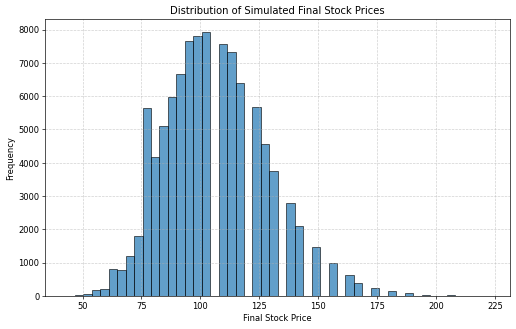

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), dpi=60)
plt.hist(simulated_stock_prices, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Simulated Final Stock Prices')
plt.xlabel('Final Stock Price')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Summary**

The implementation of the Binomial tree Monte Carlo simulation involved defining model parameters, calculating Binomial tree mechanics (up/down factors and risk-neutral probability), performing Monte Carlo simulations to generate stock price paths, calculating option payoffs for each path, and finally, computing the discounted average payoff to arrive at the option price.

The consistency between directly calculated parameters and those derived from helper functions confirms the accuracy of the Binomial tree mechanics implementation.

To refine the option price estimate, one could increase the number of steps (N) in the Binomial tree or the number of Monte Carlo simulations, especially for options with more complex payoff structures or longer maturities.